In [10]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [11]:
# ---------- Step 1: Load and Explore Iris Dataset ----------
print("=== Exploring Iris Dataset ===")
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target

=== Exploring Iris Dataset ===


In [12]:
print("First 5 rows of Iris dataset:")
print(iris_df.head())

First 5 rows of Iris dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [13]:
print("\nDataset Info:")
print(iris_df.info())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None


In [14]:
print("\nSummary Statistics for Iris dataset:")
print(iris_df.describe())


Summary Statistics for Iris dataset:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


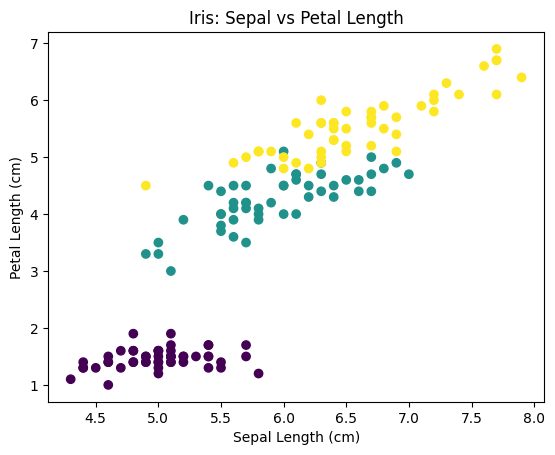

In [15]:
# Simple graph for Iris (Sepal vs Petal length)
plt.scatter(iris_df["sepal length (cm)"], iris_df["petal length (cm)"], c=iris_df["target"], cmap="viridis")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Petal Length (cm)")
plt.title("Iris: Sepal vs Petal Length")
plt.show()

In [16]:
# ---------- Step 2: Load and Explore MNIST Dataset ----------
print("\n=== Exploring MNIST Dataset ===")
(X_train, y_train), (X_test, y_test) = mnist.load_data()



=== Exploring MNIST Dataset ===


In [17]:
mnist_df = pd.DataFrame(X_train.reshape(X_train.shape[0], -1)[:1000])
mnist_df['label'] = y_train[:1000]


In [18]:
print("\nFirst 5 rows of MNIST dataset:")
print(mnist_df.head())


First 5 rows of MNIST dataset:
   0  1  2  3  4  5  6  7  8  9  ...  775  776  777  778  779  780  781  782  \
0  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
1  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
2  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
3  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   
4  0  0  0  0  0  0  0  0  0  0  ...    0    0    0    0    0    0    0    0   

   783  label  
0    0      5  
1    0      0  
2    0      4  
3    0      1  
4    0      9  

[5 rows x 785 columns]


In [19]:

print("\nDataset Info:")
print(mnist_df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 785 entries, 0 to label
dtypes: uint8(785)
memory usage: 766.7 KB
None


In [20]:

print("\nSummary Statistics for MNIST dataset (pixel values):")
print(mnist_df.drop(columns=['label']).describe())


Summary Statistics for MNIST dataset (pixel values):
          0       1       2       3       4       5       6       7       8    \
count  1000.0  1000.0  1000.0  1000.0  1000.0  1000.0  1000.0  1000.0  1000.0   
mean      0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
std       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
min       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
25%       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
50%       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
75%       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
max       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

          9    ...          774          775     776     777     778     779  \
count  1000.0  ...  1000.000000  1000.000000  1000.0  1000.0  1000.0  1000.0   
mean      0.0  ...     0.318000     0.110000     0.0    

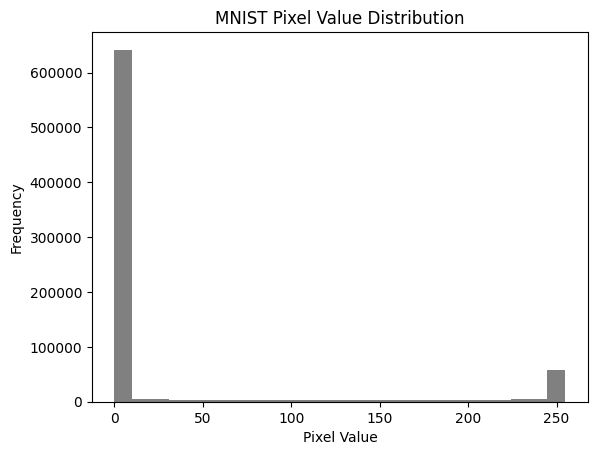

In [21]:
# Simple graph for MNIST (histogram of pixel values)
pixels = mnist_df.drop(columns=['label']).to_numpy().ravel()
plt.hist(pixels, bins=25, color="gray")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.title("MNIST Pixel Value Distribution")
plt.show()